# Day 9 - numpy

### Now a big optimization we will do is using numpy instead of python loops

Refer - https://numpy.org/doc/stable/user/quickstart.html (I don't really have that much experience in numpy that's why doing it)

2-3 things to note 
1. Uses c and fortran, so compiled not iterpreted like python
2. mostly uses ndarray which is n dimensional homogenous array, which helps as all of values are of same size (except object stored), array never changes, a new array ill be created if needed.
3. major thing !!!! -> it uses mathematical symbols (like c = a * b, where a and b are ndarrays)
4. vectorization -> is i guess as we are using symbols not for loops, and using indexes, C is taking care of that, it makes numpy have less code so less bugs, easier to read, as discussed resembles mathematic symbols, and pythonic code
5. broadcasting, will learn if have to use, what I got is we can do operations on 2 different dimensional ndarray if some conditions fulfils

Main functions on ndarray - 
1. ndarray.ndim
2. ndarray.shape
3. ndarray.size
4. ndarray.dtype

### How to create an array
we have a dtype option for each apis, default is float64
1. np.array([(1.5, 2, 3), (4, 5, 6)])
2. np.zeros((2,3))
3. np.ones((2,3,4), dtype = np.int16)
4. np.empty((2,3))
5. np.arange(start,stop,step) -> stop is not include, step can be float, so for float we can use if we want to know the definite answer for no. of values
6.  np.linspace(0,2,8)
7.  ravel -> flat it out
8.  reshape -> returns
9.  resize -> inplace
10.  you can stack 2 arrays
11.  split an array


### Some more properties
1. no copy in assignment (a=b) and func calls
2. shallow copy when view and slices, a.base = b.base ->change in the new one changes the original values
3. deep copy -> .copy()

In [1]:
import numpy as np

In [12]:
a = np.arange(10).reshape(2,5)
b = np.ones((2,5))
c = a+b
print(c)
c **= 2
print(c)
c = a * b
print(c)

[[ 1.  2.  3.  4.  5.]
 [ 6.  7.  8.  9. 10.]]
[[  1.   4.   9.  16.  25.]
 [ 36.  49.  64.  81. 100.]]
[[0. 1. 2. 3. 4.]
 [5. 6. 7. 8. 9.]]


In [14]:
c = np.arange(24).reshape(2,2,2,3)

In [17]:
c.resize(3,4,2)

c

Now we will put the coding on testing, the MLP we made, we will have to remove python list and loops to change with numpy

# Day 10

In [313]:
import numpy as np
import math
import random 

In [314]:
rg = np.random.default_rng()

In [319]:
class MLP:
    def __init__(self, layer_list, activation_list=None):
        self.w = [rg.uniform(-1,1,(layer_list[i], layer_list[i-1]))for i in range(1,len(layer_list))]
        self.w_grad = [np.zeros((layer_list[i], layer_list[i-1])) for i in range(1,len(layer_list))]
        self.b = [np.zeros(layer_list[i]).reshape(-1,1) for i in range(1,len(layer_list))]
        self.b_grad = [np.zeros(layer_list[i]).reshape(-1,1) for i in range(1,len(layer_list))]
        self.activation_list = activation_list
        self.Q = [np.zeros(layer_list[i]).reshape(1,-1) for i in range(0,len(layer_list))]
        self.output_values = None
        self.layer_list = layer_list
        
    def forward(self, inputs):
        # Reset if already has some value
        for i in range(len(self.layer_list)-1):
            self.Q[i][:] = 0
        # layer output will have output length as no. of neurons i.e. self.neurons
        self.output_values = [None] * len(self.layer_list)
        self.output_values[0] = np.array(inputs).reshape(-1,1)
        for k in range(1,len(self.layer_list)):
            self.Q[k] = self.w[k-1] @ self.output_values[k-1] + self.b[k-1]
            if self.activation_list[k-1] == 'tanh':
                self.output_values[k] = np.tanh(self.Q[k])
            elif self.activation_list[k-1] == 'ReLU':
                self.output_values[k] = np.clip(self.Q[k],a_min=0, a_max=None)
        
        return self.output_values[-1]
        
    def backward(self, loss_grad): 
        grad_in = loss_grad
        for l in range(len(self.layer_list)-1,0,-1):
            dfdq = np.ones_like(grad_in)
            if self.activation_list[l-1] == 'tanh':
                dfdq = (1-((self.output_values[l])**2))
            elif self.activation_list[l-1] == 'ReLU':
                dfdq = (self.Q[l] > 0).astype(float)
            dLdQ = grad_in * dfdq
            self.b_grad[l-1] += dLdQ
            self.w_grad[l-1] += dLdQ @ self.output_values[l-1].T
            grad_in =  self.w[l-1].T @ dLdQ
            
            
    def parameters(self):
        return (self.w, self.b)
        
    def grads(self):
        return (self.w_grad, self.b_grad)

In [320]:
class MSE:
    def __init__(self):
        pass

    def loss(self, y_pred, y_true):
        inputs = len(y_pred)
        grads = (2*(y_pred - y_true))/inputs
        ans_matrix = (y_pred-y_true)**2
        ans = sum(ans_matrix)/inputs
        return (ans, grads)


class SGD:
    def __init__(self, weights, bias, weights_grad, bias_grad, learning_rate=0.01):
        self.weights = weights
        self.bias = bias
        self.weights_grad = weights_grad
        self.bias_grad = bias_grad
        self.learning_rate = learning_rate

    def step(self):
        for i in range(len(self.weights)):
            self.weights[i] -= self.learning_rate * self.weights_grad[i]
            self.bias[i] -= self.learning_rate * self.bias_grad[i]
                    
        
    def zero_grad(self):
        for i in range(len(self.weights_grad)):
            self.weights_grad[i][:] = 0
            self.bias_grad[i][:] = 0

In [321]:
inputs = [
    [0.0, 0.0],
    [0.0, 1.0],
    [1.0, 0.0],
    [1.0, 1.0],
]
targets = np.array([[0.0], [1.0], [1.0], [0.0]])
nn = MLP([2, 4, 1], ['tanh', 'tanh'])
loss_func = MSE()
optimizer = SGD(nn.parameters()[0],nn.parameters()[1] , nn.grads()[0], nn.grads()[1], 0.5)
epochs = 1000
# Training
epoch_values = []
loss_values = []
for epoch in range(epochs):
    total_loss = 0
    for input_value, target in zip(inputs, targets):
        output = nn.forward(input_value)
        # print(f"output {output}")
        loss, loss_grad = loss_func.loss(output, target)
        total_loss += loss
        nn.backward(loss_grad)
    optimizer.step()
    optimizer.zero_grad()
    epoch_values.append(epoch)
    loss_values.append(total_loss)
    if epoch%10 == 0:
        print(f"epoch {epoch}, total loss: {total_loss}")
output = nn.forward([1.0, 1.0])
print(output)

epoch 0, total loss: [4.50832433]
epoch 10, total loss: [1.75596101]
epoch 20, total loss: [1.00439809]
epoch 30, total loss: [0.923524]
epoch 40, total loss: [1.90230692]
epoch 50, total loss: [1.18172799]
epoch 60, total loss: [1.07794894]
epoch 70, total loss: [1.0036129]
epoch 80, total loss: [1.50346244]
epoch 90, total loss: [1.39912886]
epoch 100, total loss: [1.17594639]
epoch 110, total loss: [1.20621663]
epoch 120, total loss: [1.17428941]
epoch 130, total loss: [1.12417162]
epoch 140, total loss: [1.08311579]
epoch 150, total loss: [1.05582323]
epoch 160, total loss: [1.03886291]
epoch 170, total loss: [1.02820219]
epoch 180, total loss: [1.02121671]
epoch 190, total loss: [1.01642663]
epoch 200, total loss: [1.01300663]
epoch 210, total loss: [1.0104813]
epoch 220, total loss: [1.00856466]
epoch 230, total loss: [1.00707711]
epoch 240, total loss: [1.0059013]
epoch 250, total loss: [1.00495783]
epoch 260, total loss: [1.0041913]
epoch 270, total loss: [1.00356203]
epoch 280

In [322]:
class MLP:
    def __init__(self, layer_list, activation_list=None):
        self.w = [rg.uniform(-1,1,(layer_list[i], layer_list[i-1]))for i in range(1,len(layer_list))]
        self.w_grad = [np.zeros((layer_list[i], layer_list[i-1])) for i in range(1,len(layer_list))]
        self.b = [np.zeros(layer_list[i]).reshape(-1,1) for i in range(1,len(layer_list))]
        self.b_grad = [np.zeros(layer_list[i]).reshape(-1,1) for i in range(1,len(layer_list))]
        self.activation_list = activation_list
        self.Q = [np.zeros(layer_list[i]).reshape(1,-1) for i in range(0,len(layer_list))]
        self.output_values = None
        self.layer_list = layer_list
        
    def forward(self, inputs):
        # Reset if already has some value
        for i in range(len(self.layer_list)-1):
            self.Q[i][:] = 0
        # layer output will have output length as no. of neurons i.e. self.neurons
        self.output_values = [None] * len(self.layer_list)
        self.output_values[0] = np.array(inputs).reshape(-1,1)
        for k in range(1,len(self.layer_list)):
            self.Q[k] = self.w[k-1] @ self.output_values[k-1] + self.b[k-1]
            if self.activation_list[k-1] == 'tanh':
                self.output_values[k] = np.tanh(self.Q[k])
            elif self.activation_list[k-1] == 'ReLU':
                self.output_values[k] = np.clip(self.Q[k],a_min=0, a_max=None)
        
        return self.output_values[-1]
        
    def backward(self, loss_grad): 
        grad_in = loss_grad
        for l in range(len(self.layer_list)-1,0,-1):
            dfdq = np.ones_like(grad_in)
            if self.activation_list[l-1] == 'tanh':
                dfdq = (1-((self.output_values[l])**2))
            elif self.activation_list[l-1] == 'ReLU':
                dfdq = (self.Q[l] > 0).astype(float)
            dLdQ = grad_in * dfdq
            self.b_grad[l-1] += dLdQ
            self.w_grad[l-1] += dLdQ @ self.output_values[l-1].T
            grad_in =  self.w[l-1].T @ dLdQ
            
            
    def parameters(self):
        return (self.w, self.b)
        
    def grads(self):
        return (self.w_grad, self.b_grad)

class MSE:
    def __init__(self):
        pass

    def loss(self, y_pred, y_true):
        inputs = len(y_pred)
        grads = (2*(y_pred - y_true))/inputs
        ans_matrix = (y_pred-y_true)**2
        ans = sum(ans_matrix)/inputs
        return (ans, grads)


class SGD:
    def __init__(self, weights, bias, weights_grad, bias_grad, learning_rate=0.01):
        self.weights = weights
        self.bias = bias
        self.weights_grad = weights_grad
        self.bias_grad = bias_grad
        self.learning_rate = learning_rate

    def step(self):
        for i in range(len(self.weights)):
            self.weights[i] -= self.learning_rate * self.weights_grad[i]
            self.bias[i] -= self.learning_rate * self.bias_grad[i]
                    
        
    def zero_grad(self):
        for i in range(len(self.weights_grad)):
            self.weights_grad[i][:] = 0
            self.bias_grad[i][:] = 0

In [308]:
inputs = [
    [0.0, 0.0],
    [0.0, 1.0],
    [1.0, 0.0],
    [1.0, 1.0],
]
targets = np.array([[0.0], [1.0], [1.0], [0.0]])
nn = MLP([2, 4, 1], ['tanh', 'tanh'])
loss_func = MSE()
optimizer = SGD(nn.parameters()[0],nn.parameters()[1] , nn.grads()[0], nn.grads()[1], 0.5)
epochs = 1000
# Training
epoch_values = []
loss_values = []
for epoch in range(epochs):
    total_loss = 0
    for input_value, target in zip(inputs, targets):
        output = nn.forward(input_value)
        # print("output shape:", output.shape)
        # print("target shape:", target.shape)
        loss, loss_grad = loss_func.loss(output, target)
        # print("loss_grad shape:", loss_grad.shape)
        # print("loss_grad value:", loss_grad)
        total_loss += loss
        nn.backward(loss_grad)
    optimizer.step()
    optimizer.zero_grad()
    epoch_values.append(epoch)
    loss_values.append(total_loss)
    if epoch%10 == 0:
        print(f"epoch {epoch}, total loss: {total_loss}")
output = nn.forward([1.0, 1.0])
print(output)

epoch 0, total loss: [2.61592049]
epoch 10, total loss: [1.82887355]
epoch 20, total loss: [1.99782694]
epoch 30, total loss: [1.99738015]
epoch 40, total loss: [1.99670842]
epoch 50, total loss: [1.99558862]
epoch 60, total loss: [1.99336511]
epoch 70, total loss: [1.98698757]
epoch 80, total loss: [1.90401755]
epoch 90, total loss: [1.16936883]
epoch 100, total loss: [1.07346625]
epoch 110, total loss: [0.72734096]
epoch 120, total loss: [1.06970069]
epoch 130, total loss: [0.75036764]
epoch 140, total loss: [0.68161331]
epoch 150, total loss: [0.36285391]
epoch 160, total loss: [1.92137142]
epoch 170, total loss: [1.51311048]
epoch 180, total loss: [1.4021897]
epoch 190, total loss: [1.31381042]
epoch 200, total loss: [1.27050576]
epoch 210, total loss: [1.25857763]
epoch 220, total loss: [1.25541909]
epoch 230, total loss: [1.25437508]
epoch 240, total loss: [1.2538627]
epoch 250, total loss: [1.2535053]
epoch 260, total loss: [1.2532047]
epoch 270, total loss: [1.25292941]
epoch 2

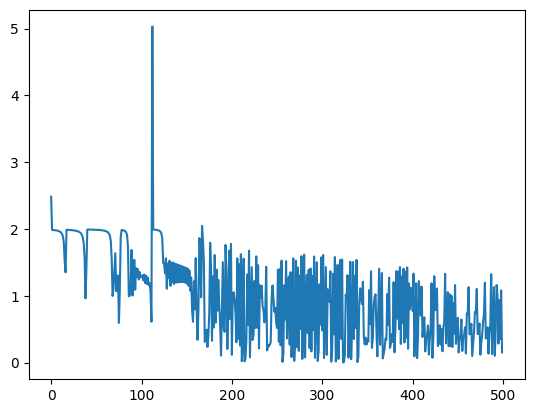

In [303]:
import matplotlib.pyplot as plt
plt.plot(epoch_values,loss_values)

In [309]:
inputs = [
    [0.0, 0.0],
    [0.0, 1.0],
    [1.0, 0.0],
    [1.0, 1.0],
]
targets = np.array([[0.0], [1.0], [1.0], [0.0]])
nn = MLP([2, 4, 1], ['tanh', 'tanh'])
loss_func = MSE()
optimizer = SGD(nn.parameters()[0],nn.parameters()[1] , nn.grads()[0], nn.grads()[1], 0.1)
epochs = 1000
# Training
epoch_values = []
loss_values = []
for epoch in range(epochs):
    total_loss = 0
    for input_value, target in zip(inputs, targets):
        output = nn.forward(input_value)
        # print("output shape:", output.shape)
        # print("target shape:", target.shape)
        loss, loss_grad = loss_func.loss(output, target)
        # print("loss_grad shape:", loss_grad.shape)
        # print("loss_grad value:", loss_grad)
        total_loss += loss
        nn.backward(loss_grad)
    optimizer.step()
    optimizer.zero_grad()
    epoch_values.append(epoch)
    loss_values.append(total_loss)
    if epoch%10 == 0:
        print(f"epoch {epoch}, total loss: {total_loss}")
output = nn.forward([1.0, 1.0])
print(output)

epoch 0, total loss: [2.22237896]
epoch 10, total loss: [0.84422504]
epoch 20, total loss: [0.74944805]
epoch 30, total loss: [0.66159277]
epoch 40, total loss: [0.56513555]
epoch 50, total loss: [0.46067678]
epoch 60, total loss: [0.35643523]
epoch 70, total loss: [0.26424509]
epoch 80, total loss: [0.19185109]
epoch 90, total loss: [0.13959666]
epoch 100, total loss: [0.10341636]
epoch 110, total loss: [0.07857441]
epoch 120, total loss: [0.06131984]
epoch 130, total loss: [0.04907946]
epoch 140, total loss: [0.04018104]
epoch 150, total loss: [0.03355148]
epoch 160, total loss: [0.0285001]
epoch 170, total loss: [0.02565523]
epoch 180, total loss: [0.16459889]
epoch 190, total loss: [0.09257423]
epoch 200, total loss: [0.03530993]
epoch 210, total loss: [0.02050294]
epoch 220, total loss: [0.01562428]
epoch 230, total loss: [0.01331588]
epoch 240, total loss: [0.01186452]
epoch 250, total loss: [0.01080229]
epoch 260, total loss: [0.00997932]
epoch 270, total loss: [0.00935321]
epoc

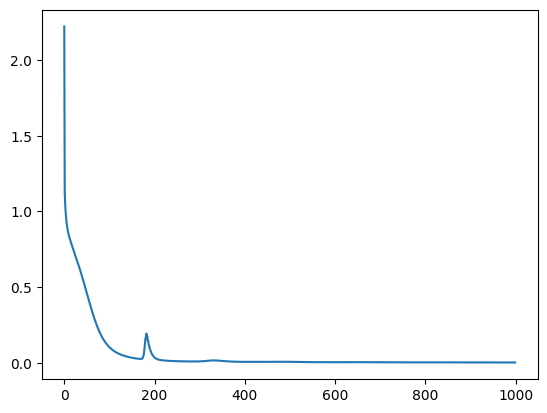

In [310]:
import matplotlib.pyplot as plt
plt.plot(epoch_values,loss_values)

In [311]:
inputs = [
    [0.0, 0.0],
    [0.0, 1.0],
    [1.0, 0.0],
    [1.0, 1.0],
]
targets = np.array([[0.0], [1.0], [1.0], [0.0]])
nn = MLP([2, 4, 1], ['tanh', 'tanh'])
loss_func = MSE()
optimizer = SGD(nn.parameters()[0],nn.parameters()[1] , nn.grads()[0], nn.grads()[1], 0.05)
epochs = 1000
# Training
epoch_values = []
loss_values = []
for epoch in range(epochs):
    total_loss = 0
    for input_value, target in zip(inputs, targets):
        output = nn.forward(input_value)
        # print("output shape:", output.shape)
        # print("target shape:", target.shape)
        loss, loss_grad = loss_func.loss(output, target)
        # print("loss_grad shape:", loss_grad.shape)
        # print("loss_grad value:", loss_grad)
        total_loss += loss
        nn.backward(loss_grad)
    optimizer.step()
    optimizer.zero_grad()
    epoch_values.append(epoch)
    loss_values.append(total_loss)
    if epoch%10 == 0:
        print(f"epoch {epoch}, total loss: {total_loss}")
output = nn.forward([1.0, 1.0])
print(output)

epoch 0, total loss: [3.39974191]
epoch 10, total loss: [1.02805694]
epoch 20, total loss: [0.94751483]
epoch 30, total loss: [0.88042729]
epoch 40, total loss: [0.81081666]
epoch 50, total loss: [0.73437259]
epoch 60, total loss: [0.64754323]
epoch 70, total loss: [0.55066822]
epoch 80, total loss: [0.44906155]
epoch 90, total loss: [0.3518425]
epoch 100, total loss: [0.26796196]
epoch 110, total loss: [0.20195016]
epoch 120, total loss: [0.1531787]
epoch 130, total loss: [0.11823058]
epoch 140, total loss: [0.09331344]
epoch 150, total loss: [0.07535704]
epoch 160, total loss: [0.06217515]
epoch 170, total loss: [0.05228978]
epoch 180, total loss: [0.04471606]
epoch 190, total loss: [0.03879491]
epoch 200, total loss: [0.03407927]
epoch 210, total loss: [0.03026054]
epoch 220, total loss: [0.0271216]
epoch 230, total loss: [0.02450683]
epoch 240, total loss: [0.02230264]
epoch 250, total loss: [0.02042467]
epoch 260, total loss: [0.01880931]
epoch 270, total loss: [0.01740786]
epoch 

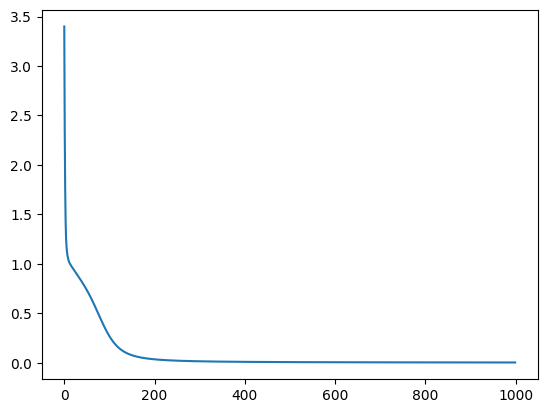

In [312]:
import matplotlib.pyplot as plt
plt.plot(epoch_values,loss_values)

In [ ]:


In our example we used only 4 inputs, but every problem is not that easy. We might need to have 10000 inputs, and also the architecture will not be this simple, there will be some additions. So for that we need to optimize. 
What can we optimize??
..
..
..
In a single neuron we are doing 3 operations
1. Multiplying all the outputs of previous layer with the corresponding weight in the neuron
2. Adding all these and bias
3. Putting a non linear function on that


First thing to think about we are using unit(), can we bypass that as right now we are not using list properly 

We are using python for loop, for calling NN.forward()
If our training samples are 10000 we would call NN.forward() 10000 times!!!!
Can we find a better approach??
..
..
As discussed we are multipl
but can we do something such that it can be done in an optimized way??
..
..
